# 共享单车用户 RFM 分层 - Part 1：数据准备 (C1-C3)

运行后生成 `../data/rfm_standardized.csv`

### C1 加载用户特征数据

In [1]:
# -*- coding: utf-8 -*-
# ============================================================
# 导入依赖库
# ============================================================
import numpy as np                # 数值计算
import pandas as pd               # 数据处理
import matplotlib.pyplot as plt   # 绘图
import seaborn as sns             # 统计可视化
from sklearn.preprocessing import StandardScaler    # 标准化
from sklearn.cluster import KMeans                  # K-Means 聚类
from sklearn.metrics import silhouette_score        # 轮廓系数

# ============================================================
# 全局显示设置
# ============================================================
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 中文用黑体
plt.rcParams["axes.unicode_minus"] = False      # 正常显示负号
pd.set_option("display.float_format", lambda x: "%.2f" % x)  # 保留两位小数




print("库导入完成")

库导入完成


In [2]:
# ============================================================
# 加载用户特征数据（Notebook A 的输出文件）
# ============================================================
df_user = pd.read_csv("../data/共享单车_用户特征.csv")

print(f"数据维度: {df_user.shape[0]} 行 x {df_user.shape[1]} 列")
print(f"用户数:   {df_user['userid'].nunique()}")
print(f"字段:     {df_user.columns.tolist()}")
df_user.head(10)


数据维度: 16883 行 x 7 列
用户数:   16883
字段:     ['userid', 'recency(day)', 'frequency(次)', 'total_distance(km)', 'total_duration(min)', 'avg_duration(min)', 'avg_speed(km/h)']


,userid,recency(day),frequency(次),total_distance(km),total_duration(min),avg_duration(min),avg_speed(km/h)
0,1,0,5,7.18,87.00,17.40,5.87
1,3,3,8,8.49,108.00,13.50,4.81
2,6,0,2,2.58,29.00,14.50,5.68
3,7,6,8,10.49,118.00,14.75,5.37
4,8,4,7,7.09,82.00,11.71,6.01
5,9,1,10,9.03,91.00,9.10,6.59
6,10,0,7,10.06,91.00,13.00,6.83
7,11,0,6,6.08,58.00,9.67,6.56
8,12,4,1,0.86,5.00,5.00,10.34
9,13,15,4,5.30,64.00,16.00,5.48


In [3]:
# ============================================================
# 数据类型与统计摘要
# ============================================================
df_user.info()
print()
print("=" * 50)
print("描述性统计")
print("=" * 50)
df_user.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16883 entries, 0 to 16882
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   userid               16883 non-null  int64  
 1   recency(day)         16883 non-null  int64  
 2   frequency(次)         16883 non-null  int64  
 3   total_distance(km)   16883 non-null  float64
 4   total_duration(min)  16883 non-null  float64
 5   avg_duration(min)    16883 non-null  float64
 6   avg_speed(km/h)      16883 non-null  float64
dtypes: float64(4), int64(3)
memory usage: 923.4 KB

描述性统计


,userid,recency(day),frequency(次),total_distance(km),total_duration(min),avg_duration(min),avg_speed(km/h)
count,16883.00,16883.00,16883.00,16883.00,16883.00,16883.00,16883.00
mean,8734.93,4.14,6.05,9.43,99.85,16.65,6.57
std,5039.44,5.27,3.48,6.43,69.31,8.72,1.37
min,1.00,0.00,1.00,0.15,2.00,2.00,0.09
25%,4388.50,0.00,3.00,4.52,48.00,11.50,5.83
50%,8723.00,2.00,6.00,8.23,86.00,15.00,6.60
75%,13033.50,6.00,8.00,12.96,138.00,19.57,7.34
max,17753.00,30.00,25.00,52.77,511.00,153.00,17.74


### C2 定义 RFM 指标

R=最近骑行天数(day) | F=骑行次数(次) | M=总里程(km)

In [4]:
# ============================================================
# 提取 RFM 三列并重命名
# R = recency(day)   最近骑行距今天数（越小越好）
# F = frequency(次)  当月骑行总次数（越大越好）
# M = total_distance(km)  当月骑行总里程（越大越好）
# ============================================================
rfm_df = df_user[["userid", "recency(day)", "frequency(次)", "total_distance(km)"]].copy()
rfm_df.columns = ["userid", "R", "F", "M"]

print(f"RFM 数据: {rfm_df.shape[0]} 个用户")
rfm_df.describe()


RFM 数据: 16883 个用户


,userid,R,F,M
count,16883.00,16883.00,16883.00,16883.00
mean,8734.93,4.14,6.05,9.43
std,5039.44,5.27,3.48,6.43
min,1.00,0.00,1.00,0.15
25%,4388.50,0.00,3.00,4.52
50%,8723.00,2.00,6.00,8.23
75%,13033.50,6.00,8.00,12.96
max,17753.00,30.00,25.00,52.77


**R 分布图**

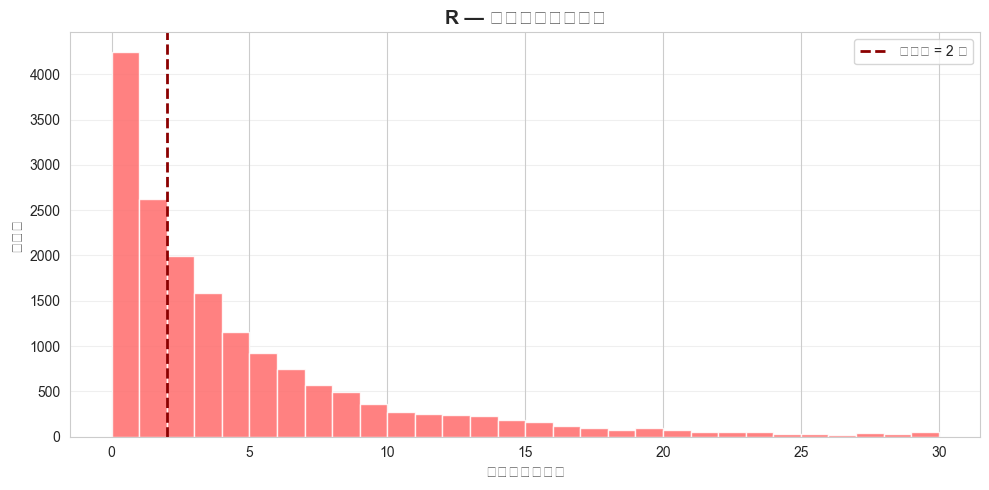

In [5]:
# ============================================================
# 图表：R 分布 — 最近骑行天数
# R 越小说明用户越活跃，关注中位数位置
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(rfm_df["R"], bins=30, color="#FF6B6B", edgecolor="white", alpha=0.85)

median_r = rfm_df["R"].median()
ax.axvline(median_r, color="darkred", linestyle="--", linewidth=2,
           label=f"中位数 = {median_r:.0f} 天")

ax.set_title("R — 最近骑行天数分布", fontsize=14, fontweight="bold")
ax.set_xlabel("距今天数（天）", fontsize=11)
ax.set_ylabel("用户数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**F 分布图**

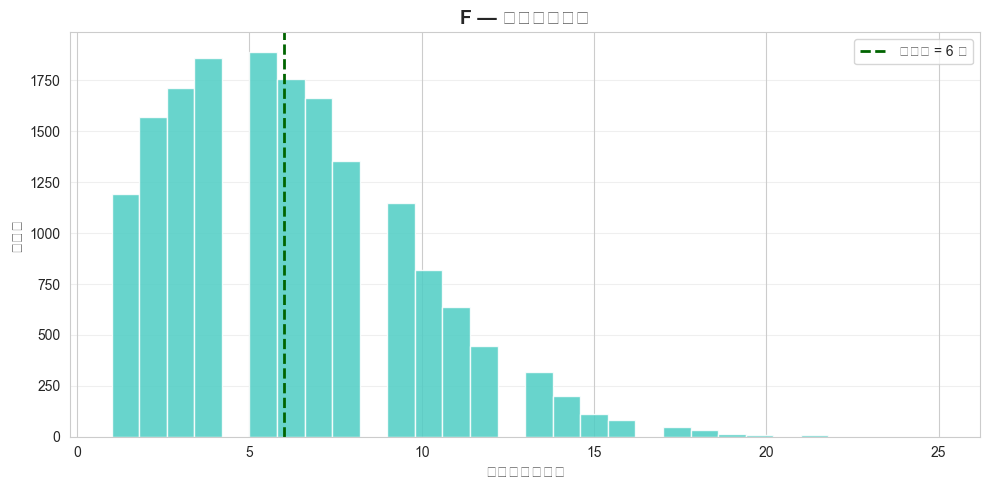

In [6]:
# ============================================================
# 图表：F 分布 — 骑行次数
# F 越大说明用户越忠诚，关注中位数位置
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(rfm_df["F"], bins=30, color="#4ECDC4", edgecolor="white", alpha=0.85)

median_f = rfm_df["F"].median()
ax.axvline(median_f, color="darkgreen", linestyle="--", linewidth=2,
           label=f"中位数 = {median_f:.0f} 次")

ax.set_title("F — 骑行次数分布", fontsize=14, fontweight="bold")
ax.set_xlabel("骑行次数（次）", fontsize=11)
ax.set_ylabel("用户数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**M 分布图**

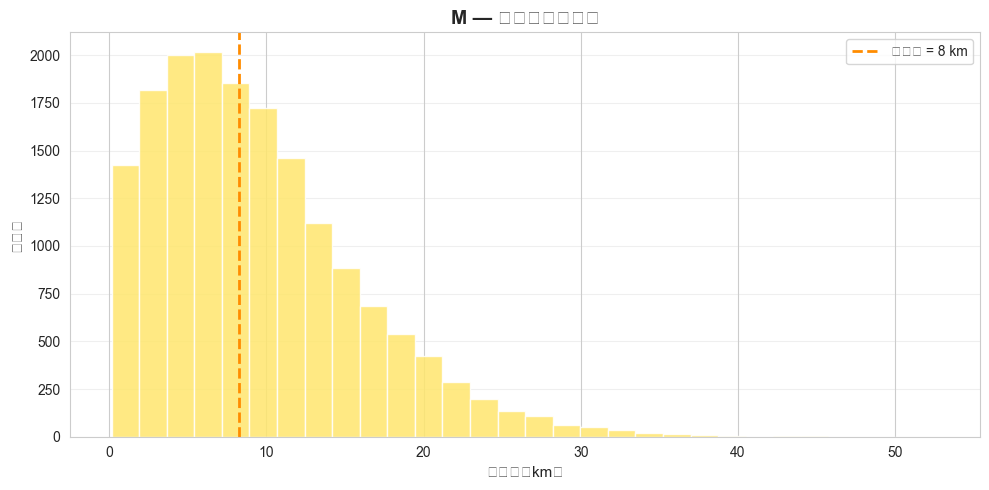

In [7]:
# ============================================================
# 图表：M 分布 — 骑行总里程
# M 越大说明用户贡献越高，关注中位数位置
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(rfm_df["M"], bins=30, color="#FFE66D", edgecolor="white", alpha=0.85)

median_m = rfm_df["M"].median()
ax.axvline(median_m, color="darkorange", linestyle="--", linewidth=2,
           label=f"中位数 = {median_m:.0f} km")

ax.set_title("M — 骑行总里程分布", fontsize=14, fontweight="bold")
ax.set_xlabel("总里程（km）", fontsize=11)
ax.set_ylabel("用户数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### C3 数据标准化（StandardScaler）

In [8]:
# ============================================================
# 数据标准化 — StandardScaler
# 将 R/F/M 转为均值为 0、标准差为 1 的 Z-score
# 消除量纲差异（天 vs 次 vs km）对聚类的影响
# ============================================================
scaler = StandardScaler()

# fit_transform：先计算均值/标准差，再转换
rfm_scaled = scaler.fit_transform(rfm_df[["R", "F", "M"]])

# 转为 DataFrame，列名加 _SC 后缀
rfm_sc = pd.DataFrame(rfm_scaled, columns=["R_SC", "F_SC", "M_SC"])

# 拼接原始值与标准化值
rfm = pd.concat([rfm_df, rfm_sc], axis=1)

print("标准化后各列统计（均值应为 0，标准差应为 1）：")
rfm[["R_SC", "F_SC", "M_SC"]].describe().round(4)


标准化后各列统计（均值应为 0，标准差应为 1）：


,R_SC,F_SC,M_SC
count,16883.00,16883.00,16883.00
mean,0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-0.79,-1.45,-1.44
25%,-0.79,-0.88,-0.76
50%,-0.41,-0.02,-0.19
75%,0.35,0.56,0.55
max,4.91,5.45,6.74


**R 标准化前后对比**

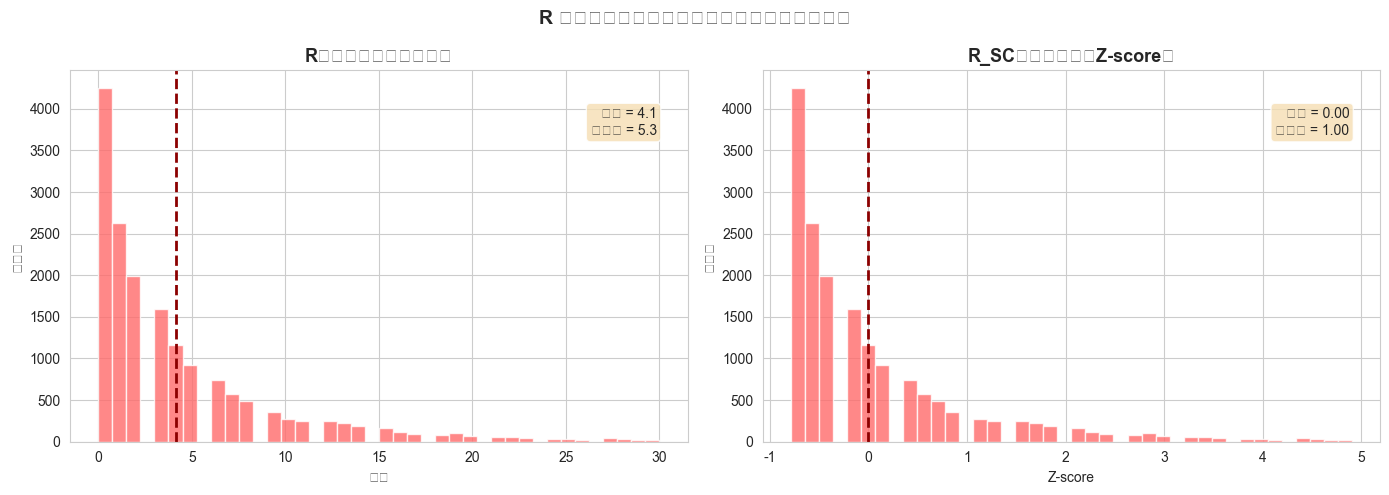

In [9]:
# ============================================================
# R 标准化前后对比
# 标准化只改变坐标轴刻度（均值→0，标准差→1），不改变分布形状
# ============================================================
r_mean_raw = rfm["R"].mean()
r_std_raw = rfm["R"].std()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左：原始 R
ax1.hist(rfm["R"], bins=40, color="#FF6B6B", edgecolor="white", alpha=0.8)
ax1.axvline(rfm["R"].mean(), color="darkred", linestyle="--", linewidth=2)
ax1.set_title("R（原始值，单位：天）", fontsize=13, fontweight="bold")
ax1.set_xlabel("天数")
ax1.set_ylabel("用户数")
# 标注均值和标准差
ax1.text(0.95, 0.90, f"均值 = {r_mean_raw:.1f}\n标准差 = {r_std_raw:.1f}",
         transform=ax1.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

# 右：标准化后 R_SC
ax2.hist(rfm["R_SC"], bins=40, color="#FF6B6B", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="darkred", linestyle="--", linewidth=2)
ax2.set_title("R_SC（标准化后，Z-score）", fontsize=13, fontweight="bold")
ax2.set_xlabel("Z-score")
ax2.set_ylabel("用户数")
ax2.text(0.95, 0.90, f"均值 = 0.00\n标准差 = 1.00",
         transform=ax2.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

plt.suptitle("R 标准化前后对比（形状相同，刻度平移缩放）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**F 标准化前后对比**

In [ ]:
# ============================================================
# F 标准化前后对比
# ============================================================
f_mean_raw = rfm["F"].mean()
f_std_raw = rfm["F"].std()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(rfm["F"], bins=40, color="#4ECDC4", edgecolor="white", alpha=0.8)
ax1.axvline(rfm["F"].mean(), color="darkgreen", linestyle="--", linewidth=2)
ax1.set_title("F（原始值，单位：次）", fontsize=13, fontweight="bold")
ax1.set_xlabel("次数")
ax1.set_ylabel("用户数")
ax1.text(0.95, 0.90, f"均值 = {f_mean_raw:.1f}\n标准差 = {f_std_raw:.1f}",
         transform=ax1.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

ax2.hist(rfm["F_SC"], bins=40, color="#4ECDC4", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="darkgreen", linestyle="--", linewidth=2)
ax2.set_title("F_SC（标准化后，Z-score）", fontsize=13, fontweight="bold")
ax2.set_xlabel("Z-score")
ax2.set_ylabel("用户数")
ax2.text(0.95, 0.90, "均值 = 0.00\n标准差 = 1.00",
         transform=ax2.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

plt.suptitle("F 标准化前后对比（形状相同，刻度平移缩放）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**M 标准化前后对比**

In [ ]:
# ============================================================
# M 标准化前后对比
# ============================================================
m_mean_raw = rfm["M"].mean()
m_std_raw = rfm["M"].std()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(rfm["M"], bins=40, color="#FFE66D", edgecolor="white", alpha=0.8)
ax1.axvline(rfm["M"].mean(), color="darkorange", linestyle="--", linewidth=2)
ax1.set_title("M（原始值，单位：km）", fontsize=13, fontweight="bold")
ax1.set_xlabel("里程（km）")
ax1.set_ylabel("用户数")
ax1.text(0.95, 0.90, f"均值 = {m_mean_raw:.1f}\n标准差 = {m_std_raw:.1f}",
         transform=ax1.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

ax2.hist(rfm["M_SC"], bins=40, color="#FFE66D", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="darkorange", linestyle="--", linewidth=2)
ax2.set_title("M_SC（标准化后，Z-score）", fontsize=13, fontweight="bold")
ax2.set_xlabel("Z-score")
ax2.set_ylabel("用户数")
ax2.text(0.95, 0.90, "均值 = 0.00\n标准差 = 1.00",
         transform=ax2.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
         fontsize=10)

plt.suptitle("M 标准化前后对比（形状相同，刻度平移缩放）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 保存中间数据

In [10]:
# ============================================================
# 保存标准化后的 RFM 数据
# ============================================================
save_df = rfm_df[["userid", "R", "F", "M"]].copy()
save_df["R_SC"] = rfm_scaled[:, 0]
save_df["F_SC"] = rfm_scaled[:, 1]
save_df["M_SC"] = rfm_scaled[:, 2]

output_path = "../data/rfm_standardized.csv"
save_df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"已保存: {output_path}")
print(f"维度: {save_df.shape[0]} 行 x {save_df.shape[1]} 列")
save_df.head()

已保存: ../data/rfm_standardized.csv
维度: 16883 行 x 7 列


,userid,R,F,M,R_SC,F_SC,M_SC
0,1,0,5,7.18,-0.79,-0.30,-0.35
1,3,3,8,8.49,-0.22,0.56,-0.15
2,6,0,2,2.58,-0.79,-1.17,-1.06
3,7,6,8,10.49,0.35,0.56,0.16
4,8,4,7,7.09,-0.03,0.27,-0.36
